# 06 · La completesa de ℝ

[Obre aquest quadern a Google Colab](https://colab.research.google.com/github/mlacasa/1BATXILLERAT/blob/main/06_Completesa_R.ipynb)

**Matemàtiques · 1r de batxillerat**  
**Autoria: Dr. Lacasa-Cazcarra · Any 2026**

**Objectiu.** Connectar suprem, intervals encaixats i successions de Cauchy sense raonaments circulars.

**Abans de començar:** quaderns 01–05  
**Temps orientatiu:** 2 sessions; demostracions avançades opcionals. Hi ha activitats bàsiques i ampliacions opcionals.

**Funcionament.** Executa les cel·les en ordre, des del començament. Primer fes una predicció,
després experimenta i escriu una justificació. Els controls són opcionals: també pots
modificar els arguments de les funcions i executar-les. Les figures representen mostres
finites; les propietats infinites necessiten una demostració.

**Procedència.** Quadern nou. Síntesi dels experiments d'Arquímedes, Dedekind i Cauchy.


In [1]:
import math
from fractions import Fraction
from decimal import Decimal, localcontext
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True,
                     "font.size": 11, "figure.dpi": 100})

def explora(funcio, **rangs):
    """Controls opcionals: la mateixa funció també es pot cridar directament."""
    # Conservem un exemple estàtic per als lectors sense controls interactius.
    funcio()
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Sense controls: executem els paràmetres per defecte. Pots canviar-los a la crida.")
        return None
    panell = widgets.interactive(funcio, **rangs)
    display(panell)
    return panell


## Ruta guiada per a 1r de batxillerat

**Pregunta de partida:** El valor més gran que es veu a la pantalla és el més gran de tot el conjunt?

**Al final ho has de poder explicar:** Distingir el màxim d'una mostra, una cota superior i el suprem del conjunt infinit.

La primera lectura combina l'exemple resolt amb el **laboratori animat** i les preguntes
que l'acompanyen. Els apartats marcats com a ampliació formal aprofundeixen en el rigor;
no cal entendre tot el codi per interpretar la matemàtica.

Dedica 2 minuts a una predicció escrita, 8–10 minuts a experimentar i pausar,
i 5 minuts a justificar una conclusió amb càlculs. Després resol el repte amb dades noves.
L'animació té controls de reproducció, pausa i selecció de fotograma.
Si el visor no mostra HTML interactiu, el fotograma estàtic i la funció
`fotograma_laboratori(...)` permeten fer la mateixa activitat pas a pas després d'executar el codi.


## 1. Màxim, cota superior i suprem
Una **cota superior** de S és un nombre M tal que $s\le M$ per a tot $s\in S$.
El **suprem** és la menor de les cotes superiors. Un **màxim** és un element de S
que és més gran o igual que tots els altres; el suprem no ha de pertànyer a S.

Per a $S=\{1-1/n:n\ge1\}$, 1 és el suprem però no és un màxim.
Qualsevol llista finita dels primers termes sí que té màxim. No confonguis la mostra amb S.


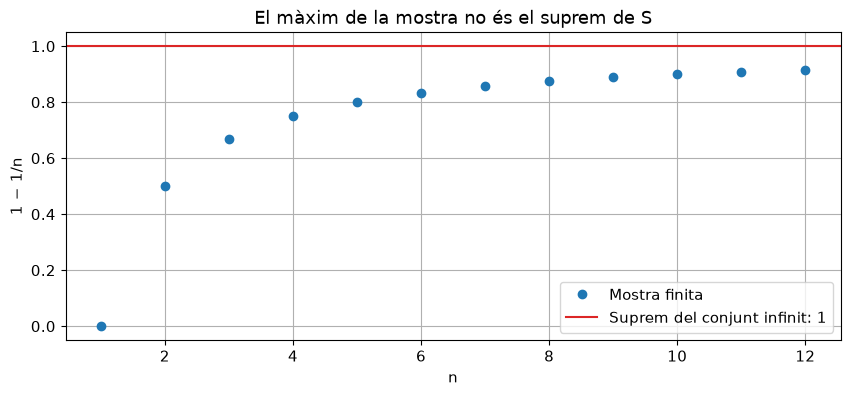

Màxim exacte de la mostra: 11/12


interactive(children=(IntSlider(value=12, description='termes', min=2), Output()), _dom_classes=('widget-inter…

In [2]:
def suprem_mostra(termes=12):
    n = np.arange(1, termes+1)
    valors = 1-1/n
    fig, ax = plt.subplots()
    ax.plot(n, valors, "o", label="Mostra finita")
    ax.axhline(1, color="#dc2626", label="Suprem del conjunt infinit: 1")
    ax.set(xlabel="n", ylabel="1 − 1/n", title="El màxim de la mostra no és el suprem de S")
    ax.legend(); plt.show()
    print("Màxim exacte de la mostra:", 1-Fraction(1, termes))
panell = explora(suprem_mostra, termes=(2, 100, 1))


## Laboratori animat · observa, atura i explica


### Una escala que s'acosta al sostre

Considera $S=\{1-1/n:n=1,2,3,\ldots\}=\{0,1/2,2/3,3/4,\ldots\}$.
Els primers cinc valors tenen màxim $4/5$. Però el següent és $5/6>4/5$:
el màxim de la **mostra** no és un màxim del **conjunt infinit**.

- **Cota superior:** un sostre que cap element supera. 1, 1,1 i 2 són cotes superiors.
- **Suprem:** el més baix dels sostres possibles. Aquí és 1.
- **Màxim:** un element del conjunt que és més gran o igual que tots els altres. Aquí no n'hi ha.

Posem a prova el candidat 0,95. Sembla un sostre si només mirem pocs termes.
Resolem $1-1/n>0{,}95$: equival a $n>20$.

**Prediu.** Què passarà als termes 20 i 21? **Pausa** just abans de 21 i just després.
La dreta mostra la distància al sostre 1; baixar no significa arribar-hi en un pas finit.


In [3]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def fotograma_laboratori(pas):
    """Mostra un estat quiet per poder llegir, dibuixar i prendre apunts."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=90)
    dibuixa_laboratori(pas, axes)
    fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .92))
    plt.show()

def anima_laboratori():
    """Animació HTML amb pausa i desplaçament manual; no necessita FFmpeg."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=80)
    def actualitza(pas):
        for ax in axes:
            ax.clear()
        dibuixa_laboratori(pas, axes)
        fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
        fig.tight_layout(rect=(0, 0, 1, .92))
    animacio = FuncAnimation(fig, actualitza, frames=fotogrames_laboratori,
                             interval=700, repeat=False, cache_frame_data=False)
    try:
        contingut = animacio.to_jshtml(fps=1.5, default_mode="once")
    finally:
        plt.close(fig)
    return HTML(contingut)


In [4]:
titol_laboratori = "Màxim visible i suprem: dues idees diferents"
fotogrames_laboratori = [1, 2, 3, 4, 5, 8, 10, 15, 19, 20, 21, 25, 30, 40, 60, 100]

def estat_suprem(n):
    maxim = 1-Fraction(1, n)
    return maxim, Fraction(1, n), maxim > Fraction(19, 20)

def dibuixa_laboratori(n, axes):
    maxim, distancia, supera = estat_suprem(n)
    ax, bx = axes
    indices = np.arange(1, n+1)
    ax.plot(indices, 1-1/indices, "o", ms=4, color="#2563eb", label="Mostra de S")
    ax.scatter(n, float(maxim), color="#ea580c", s=65, zorder=5)
    ax.axhline(1, color="#047857", label="Suprem de S: 1")
    ax.axhline(.95, color="#b91c1c", ls="--", label="Candidat: 0,95")
    ax.set(xlim=(0, 103), ylim=(-.04, 1.07), xlabel="n", ylabel="1 − 1/n",
           title=f"Mostrem {n} termes; màxim = {maxim}\n{'0,95 ja ha estat superat' if supera else 'Encara no hem superat 0,95'}")
    ax.legend(loc="lower right", fontsize=8)
    bx.semilogy(indices, 1/indices, color="#7c3aed")
    bx.scatter(n, float(distancia), color="#7c3aed", s=65)
    bx.set(xlim=(0, 103), ylim=(.008, 1.2), xlabel="n", ylabel="Distància a 1: 1/n",
           title=f"Distància exacta: {distancia}\nÉs positiva en cada pas finit")


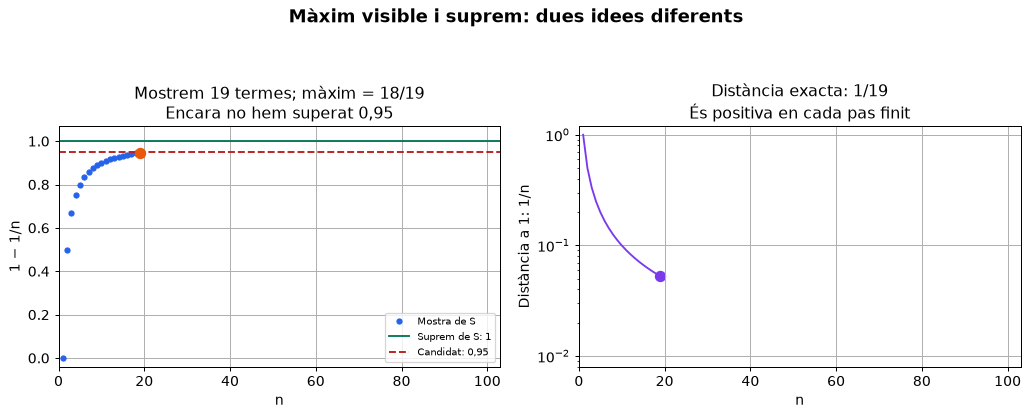

In [5]:
# Fotograma visible també quan no es reprodueix l'animació.
fotograma_laboratori(fotogrames_laboratori[len(fotogrames_laboratori)//2])


**Ara reprodueix l'animació.** Fes servir la pausa i el control de fotograma per contrastar la teva predicció. Els valors numèrics dels títols formen part de l'explicació.


In [6]:
display(anima_laboratori())


### Compara abans de concloure

Compara els termes 20 i 21: al primer arribem a 0,95 i al segon el superem. Escriu per què això refuta 0,95 com a cota superior de S, encara que semblés vàlida en una mostra més petita.

Tria dos estats amb els controls i prem **Compara els estats**. Llegeix les escales: algunes ampliacions del laboratori canvien els límits dels eixos. Justifica la comparació amb els nombres dels títols.


In [7]:
parella_comparacio = (20, 21)
etiquetes_comparacio = [f"{n} termes" for n in fotogrames_laboratori]
preguntes_taller = [{'enunciat': 'El conjunt S={1−1/n: n≥1} té màxim?', 'opcions': ['Sí: 1', 'No: qualsevol terme és superat pel següent', 'Sí: el terme n=100'], 'correcta': 1, 'retorn': ['1 és el suprem, però no pertany a S.', 'Correcte: hi ha termes cada vegada més grans, tots estrictament menors que 1.', 'El terme 101 supera el 100: un màxim de la mostra no és màxim del conjunt infinit.']}, {'enunciat': "Quin és el suprem de l'interval obert (0,1)?", 'opcions': ['1', "No existeix perquè l'interval és obert", "L'últim decimal abans d'1"], 'correcta': 0, 'retorn': ['Correcte: 1 és la cota superior més petita, encara que no pertanyi al conjunt.', "L'obertura impedeix un màxim, però no impedeix el suprem.", "No hi ha un últim nombre real abans d'1: sempre en podem trobar un altre més proper."]}, {'enunciat': 'Si cap dels primers 20 termes supera 0,95, què sabem sobre el conjunt infinit?', 'opcions': ["Que 0,95 n'és cota superior", "Que 0,95 n'és suprem", 'Encara no podem generalitzar a tots els termes'], 'correcta': 2, 'retorn': ['El terme 21 ja supera 0,95: has generalitzat una observació finita.', 'Ni tan sols és una cota superior de tot S.', 'Correcte: cal una justificació per a tots els índexs, no una mostra.']}]


In [8]:
def compara_estats(inicial, final):
    """Dos fotogrames simultanis; els eixos conserven el significat del laboratori."""
    if inicial not in fotogrames_laboratori or final not in fotogrames_laboratori:
        raise ValueError("Tria dos estats de fotogrames_laboratori.")
    fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.8), dpi=90)
    for fila, estat, lletra in [(0, inicial, "A"), (1, final, "B")]:
        dibuixa_laboratori(estat, axes[fila])
        for ax in axes[fila]:
            ax.set_title(lletra + " · " + ax.get_title(), fontsize=10)
    fig.suptitle("Comparació simultània: observa què canvia i què es conserva", fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .95), h_pad=3)
    plt.show()

def controls_comparacio():
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Canvia els dos arguments de compara_estats(...) per fer una altra comparació.")
        return None
    opcions = list(zip(etiquetes_comparacio, fotogrames_laboratori))
    panell = widgets.interactive(compara_estats, {"manual": True, "manual_name": "Compara els estats"},
        inicial=widgets.Dropdown(options=opcions, value=parella_comparacio[0], description="Estat A:"),
        final=widgets.Dropdown(options=opcions, value=parella_comparacio[1], description="Estat B:"))
    display(panell)
    return panell

def feedback_resposta(numero, lletra):
    """Retorn per opció. Ex.: feedback_resposta(1, 'B'); no desa ni envia respostes."""
    if isinstance(numero, bool) or not isinstance(numero, int) or not 1 <= numero <= len(preguntes_taller):
        raise ValueError("El número de pregunta no és vàlid.")
    q = preguntes_taller[numero-1]
    lletra = str(lletra).strip().upper()
    lletres = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"[:len(q["opcions"])]
    if lletra not in lletres or len(lletra) != 1:
        raise ValueError("Tria una de les lletres de les opcions.")
    index = lletres.index(lletra)
    return {"correcte": index == q["correcta"], "explicacio": q["retorn"][index]}

def mostra_feedback(numero, lletra):
    resultat = feedback_resposta(numero, lletra)
    estat = "Resposta encertada" if resultat["correcte"] else "Revisa el raonament"
    display(Markdown(f"**Pregunta {numero} · {estat}.** {resultat['explicacio']}"))
    return resultat

def crea_autoavaluacio():
    try:
        import ipywidgets as widgets
        from html import escape
    except ImportError:
        print("Respon amb mostra_feedback(1, 'A'), canviant la pregunta i la lletra.")
        return None
    camps, selectors = [], []
    for numero, q in enumerate(preguntes_taller, 1):
        opcions = [("Tria una resposta", None)] + [
            (f"{chr(65+k)}. {text}", chr(65+k)) for k, text in enumerate(q["opcions"])]
        selector = widgets.Dropdown(options=opcions, value=None, layout=widgets.Layout(width="100%"))
        selectors.append(selector)
        camps.append(widgets.VBox([
            widgets.HTML(f"<b>{numero}. {escape(q['enunciat'])}</b>"), selector]))
    sortida = widgets.Output()
    boto = widgets.Button(description="Comprova i raona", button_style="info", layout=widgets.Layout(width="180px"))
    def comprova(_):
        with sortida:
            sortida.clear_output(wait=True)
            for numero, selector in enumerate(selectors, 1):
                if selector.value is None:
                    display(Markdown(f"**Pregunta {numero}:** encara has de triar una resposta."))
                else:
                    mostra_feedback(numero, selector.value)
    def canvi(_):
        sortida.clear_output()
    for selector in selectors:
        selector.observe(canvi, names="value")
    boto.on_click(comprova)
    panell = widgets.VBox(camps+[boto, sortida])
    display(panell)
    return {"panell": panell, "selectors": selectors, "boto": boto, "sortida": sortida}


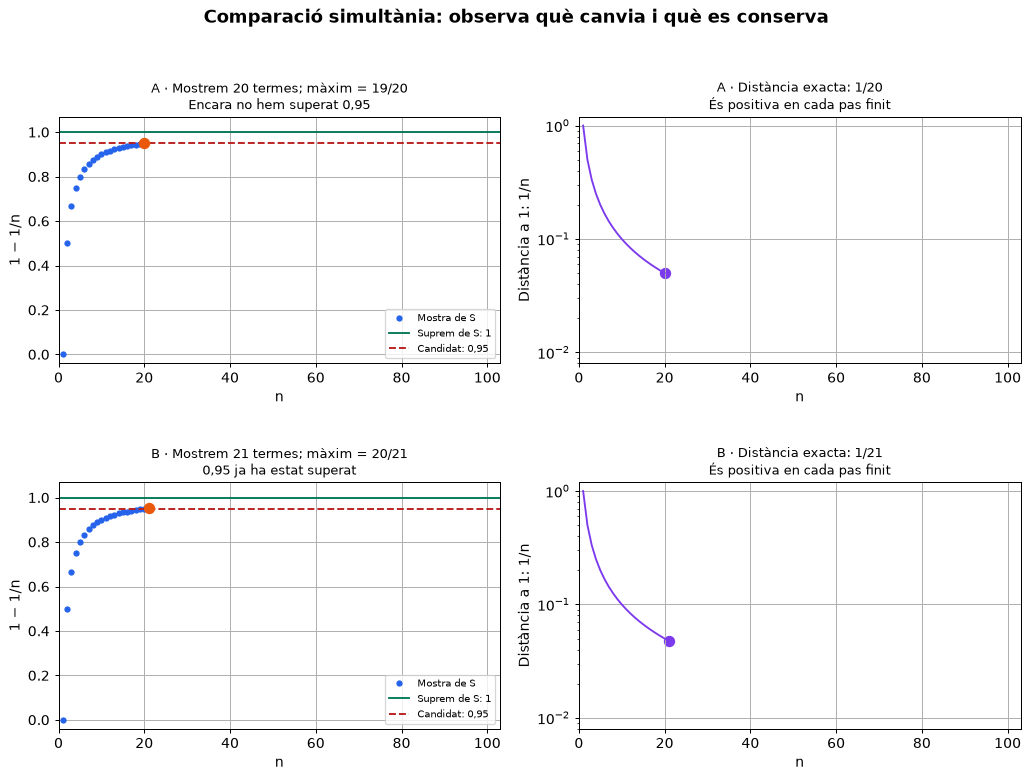

interactive(children=(Dropdown(description='Estat A:', index=9, options=(('1 termes', 1), ('2 termes', 2), ('3…

In [9]:
compara_estats(*parella_comparacio)
panell_comparacio = controls_comparacio()


### Taller de Python · canvia una dada i explica l'efecte

Escull un candidat racional M entre 0 i 1. Troba directament el primer índex amb 1−1/n>M, sense recórrer tots els termes. Dedueix abans la desigualtat n>1/(1−M).

**Fes-ho en tres passos:** escriu una predicció, modifica les dades indicades i contrasta el resultat. Acaba amb una explicació matemàtica; executar la cel·la és només una part de la tasca.


In [10]:
candidat_M = Fraction("0.999")  # Evita escriure primer un decimal float.
if not 0 < candidat_M < 1:
    raise ValueError("Aquest taller demana un candidat M entre 0 i 1.")
llindar = 1/(1-candidat_M)
primer_n = llindar.numerator//llindar.denominator+1
terme = 1-Fraction(1, primer_n)
anterior = 1-Fraction(1, primer_n-1)
print(f"Cal n > {llindar}; primer enter: {primer_n}")
print(f"Terme anterior ≤ M: {anterior <= candidat_M}")
print(f"Terme trobat > M: {terme > candidat_M}; valor exacte = {terme}")


Cal n > 1000; primer enter: 1001
Terme anterior ≤ M: True
Terme trobat > M: True; valor exacte = 1000/1001


### Atura't i comprova què has entès

Tria una resposta per pregunta i escriu una justificació abans de comprovar-la. Si t'equivoques, llegeix el retorn i torna al gràfic per localitzar el malentès.

**1. El conjunt S={1−1/n: n≥1} té màxim?**

- A. Sí: 1
- B. No: qualsevol terme és superat pel següent
- C. Sí: el terme n=100

**2. Quin és el suprem de l'interval obert (0,1)?**

- A. 1
- B. No existeix perquè l'interval és obert
- C. L'últim decimal abans d'1

**3. Si cap dels primers 20 termes supera 0,95, què sabem sobre el conjunt infinit?**

- A. Que 0,95 n'és cota superior
- B. Que 0,95 n'és suprem
- C. Encara no podem generalitzar a tots els termes

Si no es mostren els controls, executa `mostra_feedback(1, 'B')`, canviant el número i la lletra. El retorn comprova l'opció; la justificació escrita s'ha de discutir a classe.


In [11]:
autoavaluacio = crea_autoavaluacio()


### Evidència final de l'aprenentatge

Completa aquestes frases amb un cas concret del taller:

1. **He canviat…**
2. **Esperava que… perquè…**
3. **El resultat ha estat…**
4. **Ara ho explico amb aquesta relació o propietat…**
5. **Un cas en què no puc generalitzar directament és…**

Torna a una pregunta que hagis corregit i explica què has canviat del teu raonament.


### Investiga i transfereix


1. Troba un element de S més gran que 0,999. Justifica el teu índex sense provar tots els termes.
2. Per als conjunts $\{1,2,3\}$, $(0,1)$ i $[0,1]$, indica una cota superior,
   el suprem i si existeix màxim.
3. Explica per què veure els primers 100 termes no basta per assegurar una propietat de tot S.
4. **Ampliació:** quina diferència hi ha entre l'exemple concret, en què podem demostrar
   que el suprem és 1, i l'axioma que afirma l'existència del suprem de qualsevol conjunt real
   no buit i acotat superiorment?


### El teu raonament

Edita aquesta cel·la per deixar evidència del que has après.

- **Abans pensava que…**
- **He provat aquests valors…**
- **Al gràfic he observat…**
- **Ho justifico amb aquest càlcul o propietat…**
- **La meva conclusió i el seu límit són…**

No n'hi ha prou amb una captura: relaciona el dibuix, els nombres i l'explicació.


In [12]:
# Espai per al teu experiment: canvia l'índex i executa la cel·la.
# fotograma_laboratori(fotogrames_laboratori[0])
# Escriu aquí els càlculs del repte.


<details><summary>Comprovació: obre-la després d'intentar els reptes</summary>

Cal n>1000; per exemple n=1001. Per a {1,2,3}, suprem i màxim són 3
i 4 és una altra cota superior. Per a (0,1), el suprem és 1 però no hi ha màxim.
Per a [0,1], suprem i màxim són 1. L'axioma tracta tots els conjunts amb les hipòtesis
indicades: una animació d'un sol exemple no el demostra.

</details>

**Comprova el teu aprenentatge:** has interpretat els eixos i les unitats, justificat una predicció amb un càlcul i aplicat la idea a un cas nou? Una observació finita pot suggerir una propietat; una afirmació general necessita una justificació.


## 2. El punt de partida lògic · Ampliació formal
**Axioma de completesa:** tot subconjunt no buit de ℝ acotat superiorment té suprem en ℝ.

El prenem com a propietat fonamental del sistema dels reals, juntament amb les
propietats de cos ordenat. No el deduïm d'un gràfic ni d'un càlcul finit de π.
La construcció per talladures és una altra manera de donar un model d'aquest sistema.

**Propietat arquimediana.** Els naturals no estan acotats superiorment en ℝ.
En efecte, si tinguessin suprem s, s−1 no seria cota superior: existiria un natural
n>s−1, i llavors n+1>s, contradicció. Això justifica que $2^{-n}$ pot ser tan petit
com vulguem. No confonguis aquesta propietat amb l'algorisme geomètric d'Arquímedes.

## 3. Del suprem als intervals encaixats · Ampliació formal
Suposem $I_n=[a_n,b_n]$, no buits, tancats, amb $I_{n+1}\subseteq I_n$.
El conjunt dels extrems inferiors és no buit i està acotat per $b_0$.
Sigui $x=\sup\{a_n:n\ge0\}$.

Per a cada n, $a_n\le x$. A més, $b_n$ és cota superior de **tots** els $a_k$:
si $k\le n$, $a_k\le a_n\le b_n$; si $k\ge n$, $a_k\le b_k\le b_n$.
Per tant $x\le b_n$ i $x\in I_n$ per a tot n.
Si $b_n-a_n\to0$, dos punts comuns x,y haurien de satisfer
$|x-y|\le b_n-a_n$ per a tot n; això obliga $x=y$.

**Cal mirar les hipòtesis:** els intervals oberts $(0,1/n)$ són encaixats però no tenen
cap punt comú. Els intervals tancats $[0,1]$ repetits tenen molts punts comuns,
perquè la seva amplada no tendeix a zero.


In [13]:
def intervals_arrel2(passos=12):
    """Extrems racionals exactes. No calcula sqrt(2)."""
    if not isinstance(passos, int) or passos < 0:
        raise ValueError("El nombre de passos ha de ser un enter no negatiu.")
    a, b = Fraction(1), Fraction(2)
    intervals = [(a, b)]
    for _ in range(passos):
        m = (a + b) / 2
        if m * m < 2:
            a = m
        else:
            b = m
        intervals.append((a, b))
    return intervals


In [14]:
def arquimedes(passos=8, precisio=60):
    """Semiperímetres calculats amb Decimal; les xifres tenen arrodoniment."""
    if not isinstance(passos, int) or passos < 0:
        raise ValueError("El nombre de passos ha de ser un enter no negatiu.")
    if not isinstance(precisio, int) or precisio < 16:
        raise ValueError("Calen almenys 16 xifres de precisió.")
    with localcontext() as ctx:
        ctx.prec = precisio
        n, inferior, superior = 6, Decimal(3), 2 * Decimal(3).sqrt()
        files = [(n, inferior, superior)]
        for _ in range(passos):
            nova_superior = 2 * inferior * superior / (inferior + superior)
            nova_inferior = (inferior * nova_superior).sqrt()
            n, inferior, superior = 2 * n, nova_inferior, nova_superior
            files.append((n, inferior, superior))
    return files


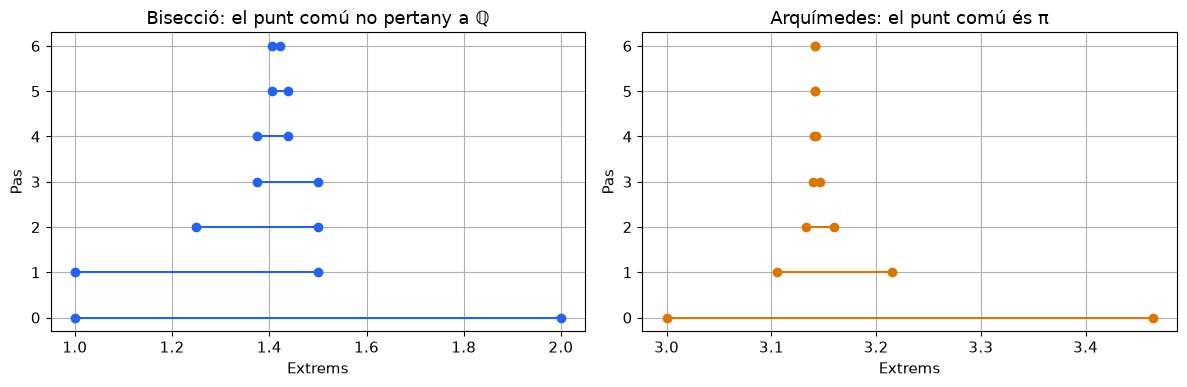

interactive(children=(IntSlider(value=6, description='passos', max=12, min=1), Output()), _dom_classes=('widge…

In [15]:
def compara_intervals(passos=6):
    racional = intervals_arrel2(passos)
    pi_intervals = arquimedes(passos)
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    for k, (a, b) in enumerate(racional):
        axs[0].plot([float(a), float(b)], [k, k], "o-", color="#2563eb")
    for k, (_, a, b) in enumerate(pi_intervals):
        axs[1].plot([float(a), float(b)], [k, k], "o-", color="#d97706")
    axs[0].set_title("Bisecció: el punt comú no pertany a ℚ")
    axs[1].set_title("Arquímedes: el punt comú és π")
    for ax in axs: ax.set(xlabel="Extrems", ylabel="Pas")
    plt.tight_layout(); plt.show()
panell = explora(compara_intervals, passos=(1, 12, 1))


## 4. Per què tota successió de Cauchy real convergeix? — Ampliació
Una successió de Cauchy és acotada. Per a cada N considerem
$$\alpha_N=\inf\{a_n:n\ge N\},\qquad \beta_N=\sup\{a_n:n\ge N\}.$$
El suprem i l'ínfim existeixen per completesa (l'ínfim es dedueix aplicant el
suprem als oposats). Els intervals $[\alpha_N,\beta_N]$ són tancats i encaixats.

Per a cada ε>0, Cauchy dona una cua amb totes les distàncies menors que ε/2;
per tant $\beta_N-\alpha_N\le\varepsilon/2<\varepsilon$.
Les amplades tendeixen a zero. El teorema anterior dona un únic punt L i,
com que tots els termes de la cua són dins l'interval, $a_n\to L$.

**Esquema de les implicacions justificades aquí:**
axioma del suprem → intervals encaixats → convergència de les successions de Cauchy.
En ℝ aquestes són formulacions equivalents de la completesa; en aquest quadern
hem demostrat les implicacions indicades, no tots els recíprocs.

## 5. Tornem al problema inicial
L'algorisme d'Arquímedes proporciona intervals encaixats d'amplada que tendeix a zero.
La completesa garanteix un únic real comú. La geometria identifica aquest real amb π.
El quadern 01 mostra que els intervals racionals poden no contenir cap racional comú.

## Activitats
1. Dona un conjunt que tingui suprem però no màxim, diferent de l'exemple inicial.
2. Per què cal que els intervals siguin tancats? Justifica el cas $(0,1/n)$.
3. Explica la funció de cadascuna d'aquestes idees: encaixament, amplada i completesa.
4. Escriu cinc frases que connectin Arquímedes, Dedekind i Cauchy sense dir que
   un càlcul numèric finit demostra la completesa.

<details><summary>Pistes</summary>

$(0,1)$ té suprem 1 i no màxim. Si x>0, existeix n amb $1/n<x$, de manera que
x no és a tots els $(0,1/n)$; 0 tampoc hi pertany. L'encaixament i la completesa
proporcionen existència en el cas tancat; l'amplada que tendeix a zero proporciona unicitat.
</details>


**Navegació:** [Anterior](05_Successions_Cauchy.ipynb) · [Índex i guia](README.md) · [Següent](07_Limits_Continuitat.ipynb)
